# Fase 6 — Decision Curve Analysis (DCA)

**Método:** Vickers & Elkin (2006) — *net benefit* = TP/N − FP/N × t/(1−t)  
**Interpretación:** una curva de modelo situada por encima de las estrategias "tratar a todos" y "no tratar a nadie" indica utilidad clínica neta en ese rango de umbrales de decisión.

**Umbrales clínicamente relevantes:**
- L1 (ingreso): 20–60 % — umbral de triaje habitual
- L2 (resultado crítico): 2–15 % — activación de vigilancia intensiva
- L3 (intervención crítica): 1–8 % — activación de respuesta rápida

El DCA complementa el AUROC al evaluar la utilidad de las predicciones en el contexto de decisiones clínicas reales, donde los costes de falsos positivos y falsos negativos dependen del umbral operativo.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

np.random.seed(42)
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

ROOT    = Path("../..").resolve()
PREDS   = pd.read_parquet(ROOT / "data/processed/predictions_test.parquet")
TARGETS = ["L1", "L2", "L3"]
MODELS  = ["logreg", "catboost", "lstm", "tabtransformer", "nam"]
LABELS  = {"logreg": "LogReg+LASSO", "catboost": "CatBoost",
           "lstm": "LSTM", "tabtransformer": "TabTransformer", "nam": "NAM"}
COLORS  = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A", "#AD1457"]
N       = len(PREDS)
print(f"Test: {N:,} pacientes")

Test: 59,641 pacientes


## 2. Función DCA

Implementación del net benefit de Vickers & Elkin (2006): `NB(t) = TP/N − FP/N × t/(1−t)`. La función `treat_all_nb` calcula la estrategia de referencia superior (tratar a todos los pacientes sin discriminar).

In [2]:
def net_benefit(y_true, y_score, thresholds):
    """Net benefit para cada umbral de decisión."""
    y = np.asarray(y_true)
    p = np.asarray(y_score)
    n = len(y)
    nb = []
    for t in thresholds:
        pred_pos = p >= t
        tp = (pred_pos & (y == 1)).sum()
        fp = (pred_pos & (y == 0)).sum()
        nb.append(tp / n - fp / n * t / (1 - t))
    return np.array(nb)

def treat_all_nb(y_true, thresholds):
    """Net benefit de tratar a todos los pacientes."""
    prev = np.asarray(y_true).mean()
    return np.array([prev - (1 - prev) * t / (1 - t) for t in thresholds])

## 3. Curvas DCA por target

Net benefit en función del umbral de probabilidad para los cinco modelos, comparado con las estrategias de referencia (tratar a todos, no tratar a nadie). Los rangos de umbral reflejan la práctica clínica habitual en urgencias para cada etiqueta.

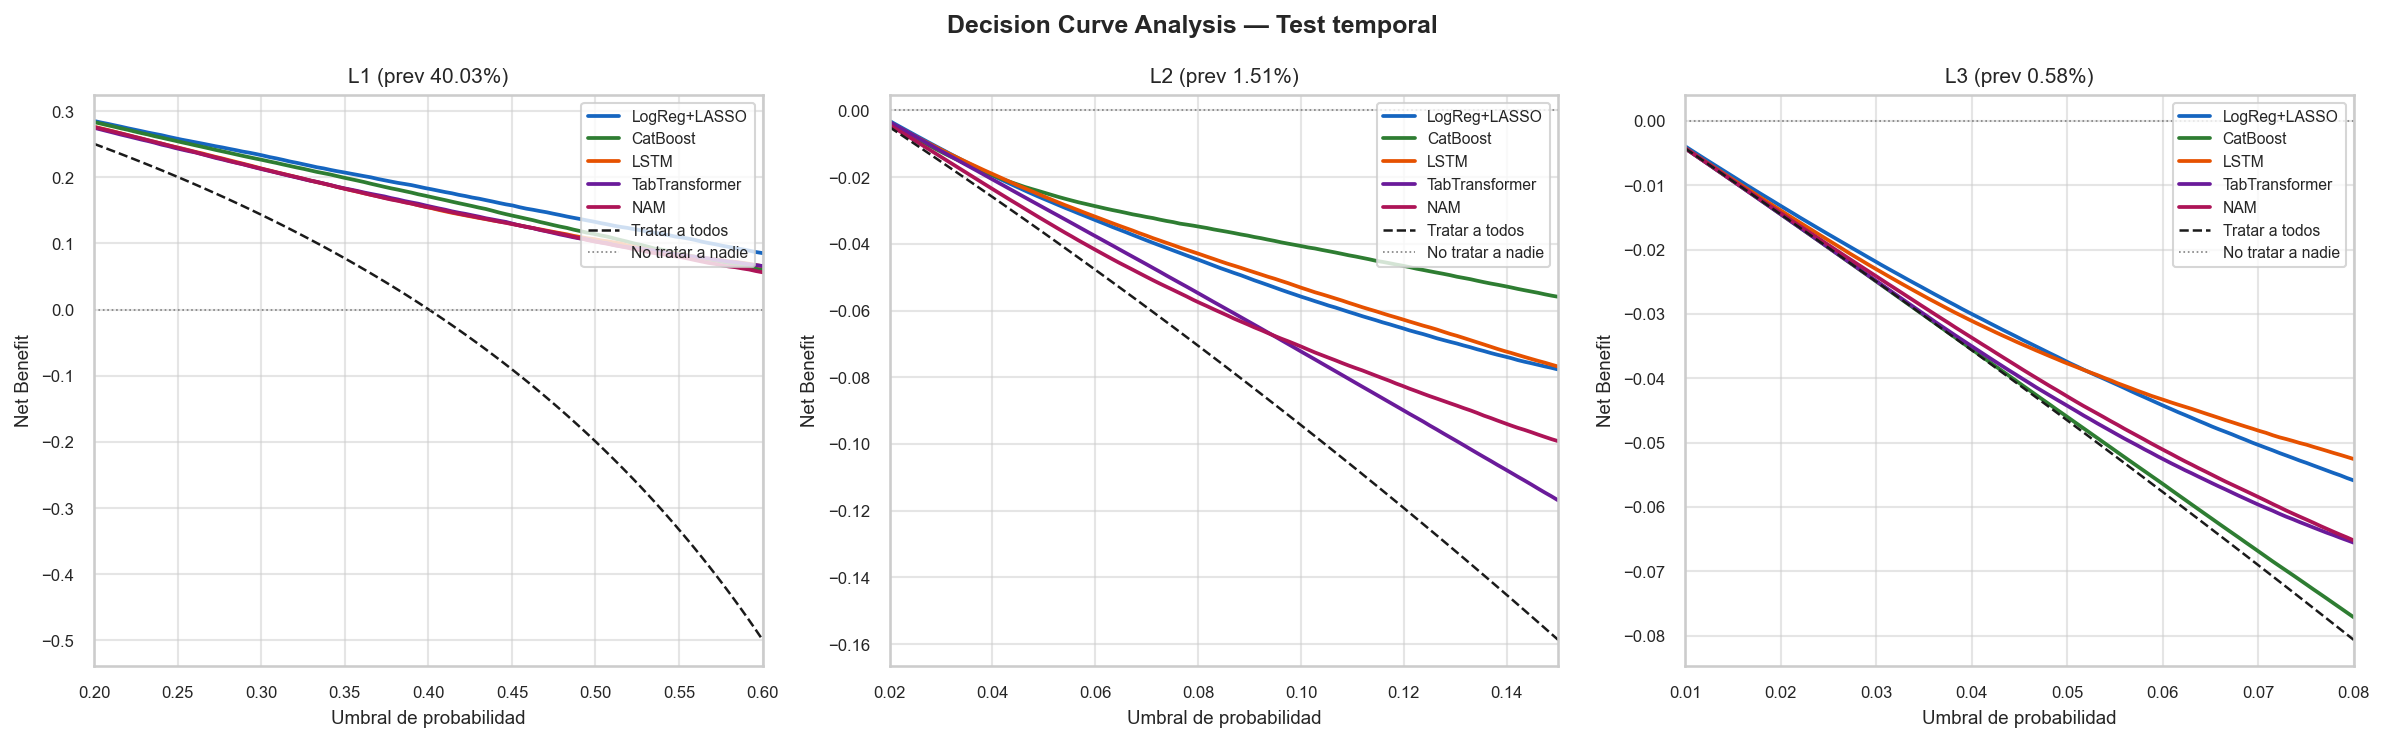

DCA guardada


In [3]:
# Rangos de umbral clínicamente relevantes por etiqueta
THRESH_RANGES = {
    "L1": np.linspace(0.20, 0.60, 100),
    "L2": np.linspace(0.02, 0.15, 100),
    "L3": np.linspace(0.01, 0.08, 100),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, t in zip(axes, TARGETS):
    y    = PREDS[f"{t}_true"].values
    thr  = THRESH_RANGES[t]
    prev = y.mean()

    for m, color in zip(MODELS, COLORS):
        p  = PREDS[f"{m}_{t}"].values
        nb = net_benefit(y, p, thr)
        ax.plot(thr, nb, color=color, lw=1.8, label=LABELS[m])

    # Estrategias de referencia
    ta_nb = treat_all_nb(y, thr)
    ax.plot(thr, ta_nb, "k--", lw=1.2, label="Tratar a todos")
    ax.axhline(0, color="gray", lw=0.8, ls=":", label="No tratar a nadie")

    ax.set_xlim(thr[0], thr[-1])
    ax.set_xlabel("Umbral de probabilidad", fontsize=9)
    ax.set_ylabel("Net Benefit", fontsize=9)
    ax.set_title(f"{t} (prev {prev*100:.2f}%)", fontsize=10)
    ax.legend(fontsize=7.5, loc="upper right")
    ax.tick_params(labelsize=8)

plt.suptitle("Decision Curve Analysis — Test temporal", fontsize=12, fontweight="bold")
plt.tight_layout()
FIG = ROOT / "reports/figures"
plt.savefig(FIG / "test_dca.png", dpi=150, bbox_inches="tight")
plt.show()
print("DCA guardada")

La Decision Curve Analysis muestra que todos los modelos proporcionan beneficio neto positivo frente a las estrategias de referencia ("tratar a todos" y "no tratar a ninguno") en los rangos de umbral de probabilidad clínicamente plausibles. En L1 (ingreso hospitalario), los modelos se agrupan estrechamente y dominar la estrategia "tratar a todos" desde umbrales superiores a 0,10, lo que indica que su uso reduciría intervenciones innecesarias manteniendo la sensibilidad. En L2 y L3 (eventos raros), el beneficio neto es especialmente relevante a umbrales bajos (0,01–0,05), coherente con el contexto clínico donde el coste de un falso negativo es crítico. No se observan diferencias sustanciales entre modelos en términos de utilidad clínica neta, a pesar de las diferencias en AUROC.

## 4. Serialización numérica del DCA

Se exportan los valores numéricos de net benefit por modelo, target y umbral. Esto permite reproducir las curvas DCA en el manuscrito sin re-ejecutar el notebook, y facilita comparaciones post-hoc.

In [4]:
rows = []
for t in TARGETS:
    y   = PREDS[f"{t}_true"].values
    thr = THRESH_RANGES[t]

    # Estrategias de referencia
    ta = treat_all_nb(y, thr)
    for thresh, nb_val in zip(thr, ta):
        rows.append({"Target": t, "Modelo": "Tratar_a_todos", "Umbral": round(thresh, 6), "Net_Benefit": round(nb_val, 6)})
    for thresh in thr:
        rows.append({"Target": t, "Modelo": "No_tratar", "Umbral": round(thresh, 6), "Net_Benefit": 0.0})

    # Cinco modelos
    for m in MODELS:
        nb = net_benefit(y, PREDS[f"{m}_{t}"].values, thr)
        for thresh, nb_val in zip(thr, nb):
            rows.append({"Target": t, "Modelo": LABELS[m], "Umbral": round(thresh, 6), "Net_Benefit": round(nb_val, 6)})

df_dca = pd.DataFrame(rows)

out = ROOT / "reports/tables"
out.mkdir(parents=True, exist_ok=True)
df_dca.to_csv(out / "test_dca.csv", index=False)

print(f"test_dca.csv guardado ({len(df_dca):,} filas)")
print(f"   Columnas: {list(df_dca.columns)}")
print(f"   Modelos: {df_dca['Modelo'].unique().tolist()}")
print(f"   Targets: {df_dca['Target'].unique().tolist()}")
print()

# Net benefit al umbral central de cada target como verificación
print("=== Net Benefit al umbral central por modelo ===")
for t in TARGETS:
    thr_range = THRESH_RANGES[t]
    mid_thresh = thr_range[len(thr_range) // 2]
    sub = df_dca[(df_dca["Target"] == t) & (df_dca["Umbral"].between(mid_thresh - 0.001, mid_thresh + 0.001))]
    print(f"\n{t} @ umbral ~ {mid_thresh:.3f}:")
    print(sub[["Modelo", "Net_Benefit"]].sort_values("Net_Benefit", ascending=False).to_string(index=False))

test_dca.csv guardado (2,100 filas)
   Columnas: ['Target', 'Modelo', 'Umbral', 'Net_Benefit']
   Modelos: ['Tratar_a_todos', 'No_tratar', 'LogReg+LASSO', 'CatBoost', 'LSTM', 'TabTransformer', 'NAM']
   Targets: ['L1', 'L2', 'L3']

=== Net Benefit al umbral central por modelo ===

L1 @ umbral ~ 0.402:
        Modelo  Net_Benefit
  LogReg+LASSO     0.181664
      CatBoost     0.169812
TabTransformer     0.155161
           NAM     0.153580
          LSTM     0.153152
     No_tratar     0.000000
Tratar_a_todos    -0.002885

L2 @ umbral ~ 0.086:
        Modelo  Net_Benefit
     No_tratar     0.000000
      CatBoost    -0.036396
          LSTM    -0.045941
  LogReg+LASSO    -0.048003
TabTransformer    -0.059715
           NAM    -0.061462
Tratar_a_todos    -0.077195

L3 @ umbral ~ 0.045:
        Modelo  Net_Benefit
     No_tratar     0.000000
     No_tratar     0.000000
     No_tratar     0.000000
  LogReg+LASSO    -0.033500
  LogReg+LASSO    -0.034045
          LSTM    -0.034307
  LogReg+